<a href="https://colab.research.google.com/github/sadasivam009/bike-sharing-demand-reg-/blob/main/CLUS_%5B_Uber_Pickups_in_New_York_City%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ** Uber Pickups in New York City**

CLUSTERING

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [33]:
import zipfile

with zipfile.ZipFile('/content/sample_data/archive (3).zip', 'r') as z:
    # Assuming you want to read 'uber-raw-data-apr14.csv'
    # You can change this to any other .csv file listed in the error message if needed.
    with z.open('uber-raw-data-apr14.csv') as f:
        df = pd.read_csv(f)

In [34]:
df

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512
...,...,...,...,...
564511,4/30/2014 23:22:00,40.7640,-73.9744,B02764
564512,4/30/2014 23:26:00,40.7629,-73.9672,B02764
564513,4/30/2014 23:31:00,40.7443,-73.9889,B02764
564514,4/30/2014 23:32:00,40.6756,-73.9405,B02764


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


In [36]:
df.shape

(564516, 4)

In [37]:
df.isnull().sum()

,0
Date/Time,0
Lat,0
Lon,0
Base,0


In [38]:
df.describe()

,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


In [39]:
x = df.iloc[:,:]

In [45]:
pca = PCA(n_components=2,random_state=42)
x_pca = pca.fit_transform(X_pca)

In [46]:
x_pca

array([[ 0.02363917,  0.02760861],
       [-0.0583854 , -0.00977347],
       [-0.0109748 , -0.00775228],
       ...,
       [-0.01179968,  0.0050215 ],
       [ 0.03233383, -0.06649411],
       [ 0.0128253 , -0.05288282]])

In [47]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(1.0)

In [48]:
distortion = []
for i in range(1,15):
  kmeans = KMeans(n_clusters=1,random_state=42)
  kmeans.fit(x_pca)
  distortion.append(kmeans.inertia_)

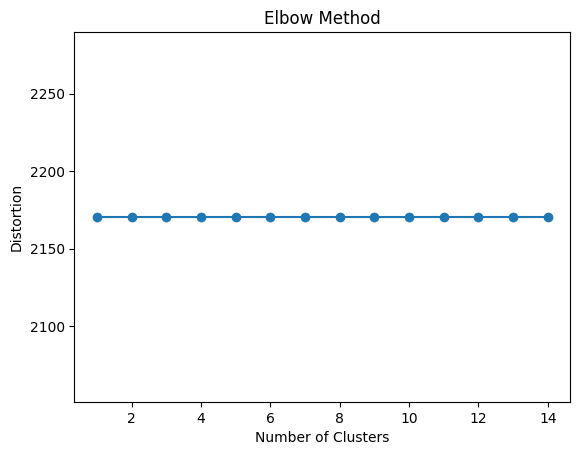

In [49]:
plt.plot(range(1,15),distortion,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()

In [51]:
model = KMeans(n_clusters=3,random_state=42)
model.fit(x_pca)

KMeans(n_clusters=3, random_state=42)

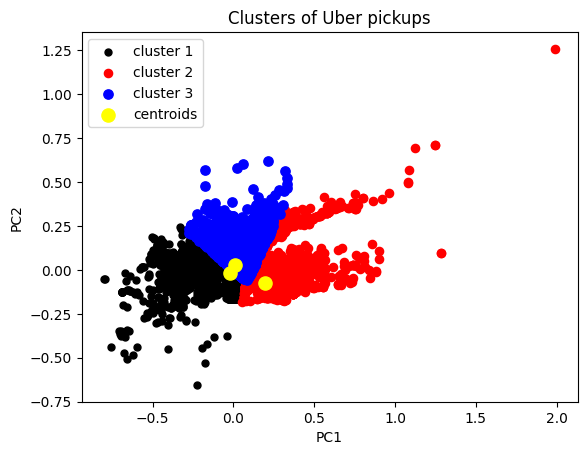

In [56]:
y = model.labels_
plt.scatter(x_pca[y==0,0],x_pca[y==0,1],s=25,c='black',label='cluster 1')
plt.scatter(x_pca[y==1,0],x_pca[y==1,1],s=35,c='red',label='cluster 2')
plt.scatter(x_pca[y==2,0],x_pca[y==2,1],s=45,c='blue',label='cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=90,c='yellow',label='centroids')
plt.title('Clusters of Uber pickups')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()